# مشروع استخراج وتصحيح نصوص الخط اليدوي

### **الخلية 1: تثبيت المكتبات المطلوبة**

In [1]:
# تثبيت جميع المكتبات المطلوبة
!apt-get install -y poppler-utils tesseract-ocr
!pip install -q pdf2image easyocr pyspellchecker langdetect pytesseract transformers torch torchvision Pillow opencv-python-headless pandas ar-corrector ipywidgets scikit-learn fpdf2
# تثبيت المكتبات الإضافية لنظام التحسين المستمر
!pip install -q peft huggingface_hub datasets

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 2s (115 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
 

### **الخلية 2: الاستيرادات وإعداد المسارات**

In [2]:
# =============== الخلية 2 (معدلة لتأخذ الـ token من Secrets) ===============
from google.colab import userdata
import os

# جلب التوكن المخزن في Secrets (الاسم يجب أن يكون "HF_TOKEN" تماماً)
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("✅ تم تحميل Hugging Face Token من Colab Secrets")
except userdata.SecretNotFoundError:
    print("⚠️ لم يتم العثور على Secret باسم 'HF_TOKEN'. تأكد من إنشائه ونفس الاسم.")
    print("   يمكنك استخدام login() بدلاً من ذلك إن لم يكن لديك Secret.")
except Exception as e:
    print(f"خطأ غير متوقع: {e}")

import cv2, numpy as np, sqlite3, io, torch, json, time, logging
import pandas as pd, easyocr
from PIL import Image
from pdf2image import convert_from_path
from google.colab import drive, patches
from spellchecker import SpellChecker
from langdetect import detect, DetectorFactory
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from ar_corrector.corrector import Corrector
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات الثابتة
MODEL_CACHE = '/content/drive/MyDrive/Handwriting_Dataset/models_cache'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"] = MODEL_CACHE
os.environ["TORCH_HOME"] = MODEL_CACHE

PDF_PATH = '/content/drive/MyDrive/python notes.pdf'
OUTPUT_DIR = '/content/drive/MyDrive/Handwriting_Dataset'
LOGS_DIR = os.path.join(OUTPUT_DIR, 'Logs')
os.makedirs(LOGS_DIR, exist_ok=True)

DB_PATH = os.path.join(OUTPUT_DIR, 'handwriting_data.db')
LOG_FILE = os.path.join(LOGS_DIR, f"ocr_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
FEEDBACK_CSV = os.path.join(LOGS_DIR, "user_corrections_feedback.csv")
STATS_JSON = os.path.join(LOGS_DIR, "processing_stats.json")

# إعداد logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler(LOG_FILE, encoding='utf-8'), logging.StreamHandler()]
)

if not os.path.exists(FEEDBACK_CSV):
    pd.DataFrame(columns=['timestamp', 'image_id', 'original_text', 'corrected_text', 'status']).to_csv(FEEDBACK_CSV, index=False, encoding='utf-8')

logging.info("🚀 بدء تشغيل المشروع")

✅ تم تحميل Hugging Face Token من Colab Secrets
Mounted at /content/drive


### **الخلية 3: تحميل النماذج (TrOCR، EasyOCR، المدققات)**

In [3]:
print("جاري فحص النماذج المحملة مسبقاً...")
start_time = time.time()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"الجهاز المستخدم: {device}")

# TrOCR - سيتم التحميل مرة واحدة فقط بسبب cache_dir
try:
    trocr_processor = TrOCRProcessor.from_pretrained("David-Magdy/TR_OCR_LARGE", cache_dir=MODEL_CACHE)
    trocr_model = VisionEncoderDecoderModel.from_pretrained("David-Magdy/TR_OCR_LARGE", cache_dir=MODEL_CACHE).to(device)
    print("✅ TrOCR جاهز (من الكاش)")
except Exception as e:
    print(f"فشل تحميل TrOCR: {e}")

# تحميل نموذج LoRA المُحسّن إذا كان موجودًا
lora_save_path = os.path.join(MODEL_CACHE, 'trocr_lora_finetuned')
if os.path.exists(lora_save_path):
    from peft import PeftModel
    try:
        trocr_model = PeftModel.from_pretrained(trocr_model, lora_save_path).to(device)
        print("✅ تم تحميل النموذج المُحسَّن (LoRA) من الكاش")
    except Exception as e:
        print(f"⚠️ فشل تحميل نموذج LoRA: {e}. سيتم استخدام النموذج الأساسي.")
else:
    print("ℹ️ يستخدم النموذج الأساسي (لا يوجد fine-tuning بعد)")

# EasyOCR
import easyocr
import os.path as osp
EASYOCR_DIR = osp.expanduser("~/.EasyOCR")
detect_model_path = osp.join(EASYOCR_DIR, "model/craft_mlt_25k.pth")
recog_model_path = osp.join(EASYOCR_DIR, "model/english_g2.pth")

easy_reader = easyocr.Reader(['en', 'ar'])

# المدققات الإملائية
arabic_spell = Corrector()
english_spell = SpellChecker(language='en')
DetectorFactory.seed = 0

logging.info(f"✅ تم التحميل في {time.time()-start_time:.2f} ثانية")

جاري فحص النماذج المحملة مسبقاً...


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/636 [00:03<?, ?it/s]

✅ TrOCR جاهز (من الكاش)
ℹ️ يستخدم النموذج الأساسي (لا يوجد fine-tuning بعد)
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [4]:
# تحويل نماذج EasyOCR لتكون دائمة على Drive
import os

drive_easyocr_path = '/content/drive/MyDrive/Handwriting_Dataset/.EasyOCR'
local_easyocr_path = os.path.expanduser('~/.EasyOCR')

# إذا لم تكن النماذج منقولة مسبقاً إلى Drive، قم بنقلها
if not os.path.exists(drive_easyocr_path) and os.path.exists(local_easyocr_path):
    print('جاري نقل نماذج EasyOCR إلى Drive للمرة الأولى...')
    !mv {local_easyocr_path} {drive_easyocr_path}

# إنشاء الرابط الرمزي لضمان وصول المكتبة للنماذج من Drive
if not os.path.islink(local_easyocr_path):
    if os.path.exists(local_easyocr_path):
        !rm -rf {local_easyocr_path}
    !ln -s {drive_easyocr_path} {local_easyocr_path}
    print('✅ تم ربط نماذج EasyOCR بـ Google Drive بنجاح')

✅ تم ربط نماذج EasyOCR بـ Google Drive بنجاح


### **الخلية 4: دوال المعالجة المسبقة والتعرف والتصحيح**

In [5]:
import json
import os.path as osp

# =============== إضافات دعم التقدم وحفظ الحالة ===============
CHECKPOINT_FILE = os.path.join(OUTPUT_DIR, 'ocr_checkpoint.json')

def save_checkpoint(page_num, total_pages, processed_words, last_image_id=None):
    checkpoint = {
        'last_page_processed': page_num,
        'total_pages': total_pages,
        'processed_words': processed_words,
        'last_image_id': last_image_id,
        'timestamp': datetime.now().isoformat()
    }
    with open(CHECKPOINT_FILE, 'w', encoding='utf-8') as f:
        json.dump(checkpoint, f, indent=2, ensure_ascii=False)
    logging.info(f"💾 تم حفظ checkpoint: الصفحة {page_num}/{total_pages}")

def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

def clear_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        logging.info("🗑️ تم مسح checkpoint")

def build_correction_dict():
    CORRECTION_DICT_PATH = os.path.join(OUTPUT_DIR, 'correction_dict.json')
    if not os.path.exists(FEEDBACK_CSV):
        return {}
    try:
        df_fb = pd.read_csv(FEEDBACK_CSV, encoding='utf-8')
        corrections = {}
        for _, row in df_fb.iterrows():
            orig = str(row['original_text']).strip()
            corr = str(row['corrected_text']).strip()
            if orig and corr and orig != corr:
                if orig not in corrections: corrections[orig] = {}
                corrections[orig][corr] = corrections[orig].get(corr, 0) + 1
        final_dict = {}
        for orig, candidates in corrections.items():
            best = max(candidates, key=candidates.get)
            if candidates[best] >= 2:
                final_dict[orig] = best
        with open(CORRECTION_DICT_PATH, 'w', encoding='utf-8') as f:
            json.dump(final_dict, f, ensure_ascii=False, indent=2)
        return final_dict
    except: return {}

def apply_correction_dict(text, correction_dict):
    if not correction_dict or not text: return text
    words = text.split()
    return ' '.join([correction_dict.get(w, w) for w in words])

def preprocess_image(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=30)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return binary

def smart_word_segmentation(img_bgr, binary_img, existing_detections=None):
    word_boxes = []
    if existing_detections:
        for (bbox, text, conf) in existing_detections:
            pts = np.array(bbox, dtype=np.int32)
            x, y, w, h = cv2.boundingRect(pts)
            word_boxes.append((x, y, w, h))
        return word_boxes
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25,5))
    dilated = cv2.dilate(binary_img, kernel, iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw > 15 and bh > 10: word_boxes.append((x, y, bw, bh))
    return word_boxes

def recognize_word_ensemble(img_bgr, easyocr_raw=None):
    results = []
    try:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        inputs = trocr_processor(images=Image.fromarray(rgb), return_tensors="pt").pixel_values.to(device)
        generated_ids = trocr_model.generate(inputs, max_length=50)
        trocr_text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        results.append(('trocr', trocr_text, 0.7))
    except: pass
    if easyocr_raw:
        results.append(('easyocr', easyocr_raw[1], easyocr_raw[2]))
    if not results: return "", 0.0, "none", True
    best = max(results, key=lambda x: x[2])
    return best[1], best[2], best[0], (best[2] < 0.5)

def correct_text(text):
    if not text: return ""
    try:
        lang = detect(text)
        if lang == 'ar': return arabic_spell.contextual_correct(text)
        else:
            words = text.split()
            corrected = [english_spell.correction(w) or w for w in words]
            return ' '.join(corrected)
    except: return text

### **الخلية 5: دالة معالجة PDF وحفظ البيانات في SQLite مع تسجيل الإحصائيات**

In [6]:
def process_pdf(pages_start=1, pages_end=2, resume=True):
    proc_start = time.time()
    checkpoint = load_checkpoint() if resume else None
    if checkpoint:
        print(f"🔄 استئناف من الصفحة {checkpoint['last_page_processed']}")
        pages_start = checkpoint['last_page_processed']

    correction_dict = build_correction_dict()
    try:
        images = convert_from_path(PDF_PATH, dpi=300, first_page=pages_start, last_page=pages_end)
    except Exception as e:
        logging.error(f"فشل معالجة PDF: {e}"); return

    total_words_processed = checkpoint.get('processed_words', 0) if checkpoint else 0
    with sqlite3.connect(DB_PATH) as conn:
        conn.execute('''CREATE TABLE IF NOT EXISTS handwriting_data
                        (image_id INTEGER PRIMARY KEY AUTOINCREMENT,
                         image_data BLOB, predicted_text TEXT, status TEXT,
                         confidence REAL, model_source TEXT,
                         x INTEGER, y INTEGER, w INTEGER, h INTEGER, page_num INTEGER)''')

        # ✅ أضف هذا قبل حلقة for idx, pil in enumerate(images):
        conn.execute(
            "DELETE FROM handwriting_data WHERE page_num BETWEEN ? AND ?",
            (pages_start, pages_end)
        )
        conn.commit()
        logging.info(f"🗑️ تم مسح بيانات الصفحات {pages_start}-{pages_end} قبل إعادة المعالجة")

        for idx, pil in enumerate(images):
            actual_page = pages_start + idx
            img_bgr = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
            try: detections = easy_reader.readtext(img_bgr, detail=1)
            except: detections = []

            binary = preprocess_image(img_bgr)
            boxes_info = []
            if detections:
                for (bbox, text, conf) in detections:
                    pts = np.array(bbox, dtype=np.int32)
                    x, y, w, h = cv2.boundingRect(pts)
                    boxes_info.append(((x,y,w,h), (bbox, text, conf)))
            else:
                manual_boxes = smart_word_segmentation(img_bgr, binary)
                for box in manual_boxes: boxes_info.append((box, None))

            for (box, e_raw) in boxes_info:
                x, y, w, h = box
                crop = img_bgr[y:y+h, x:x+w]
                raw, conf, src, _ = recognize_word_ensemble(crop, easyocr_raw=e_raw)
                final = apply_correction_dict(correct_text(raw), correction_dict)
                _, buf = cv2.imencode(".png", crop)
                conn.execute('''INSERT INTO handwriting_data
                                (image_data, predicted_text, status, confidence, model_source, x, y, w, h, page_num)
                                VALUES (?,?,?,?,?,?,?,?,?,?)''',
                             (buf.tobytes(), final, 'unverified', conf, src, x, y, w, h, actual_page))
                total_words_processed += 1

            save_checkpoint(actual_page + 1, pages_end, total_words_processed)
            patches.cv2_imshow(cv2.resize(img_bgr, (0,0), fx=0.3, fy=0.3))
        conn.commit()

    clear_checkpoint()
    stats = {"timestamp": datetime.now().isoformat(), "pages": pages_end-pages_start+1, "words": total_words_processed}
    with open(STATS_JSON, 'w', encoding='utf-8') as f: json.dump(stats, f, ensure_ascii=False)
    logging.info(f"✅ اكتملت المعالجة في {time.time()-proc_start:.2f} ثانية.")

### **الخلية 6: تشغيل عملية الاستخراج (يُرجى تعديل عدد الصفحات حسب الحاجة)**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


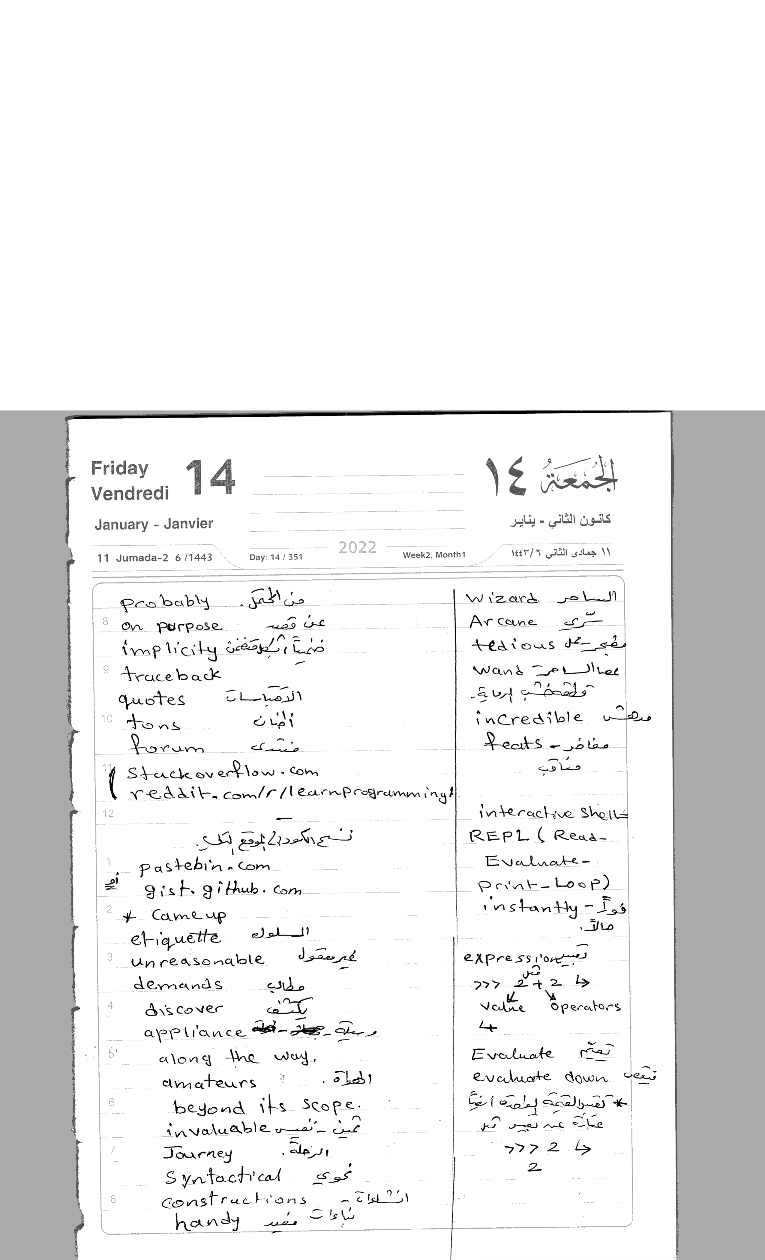

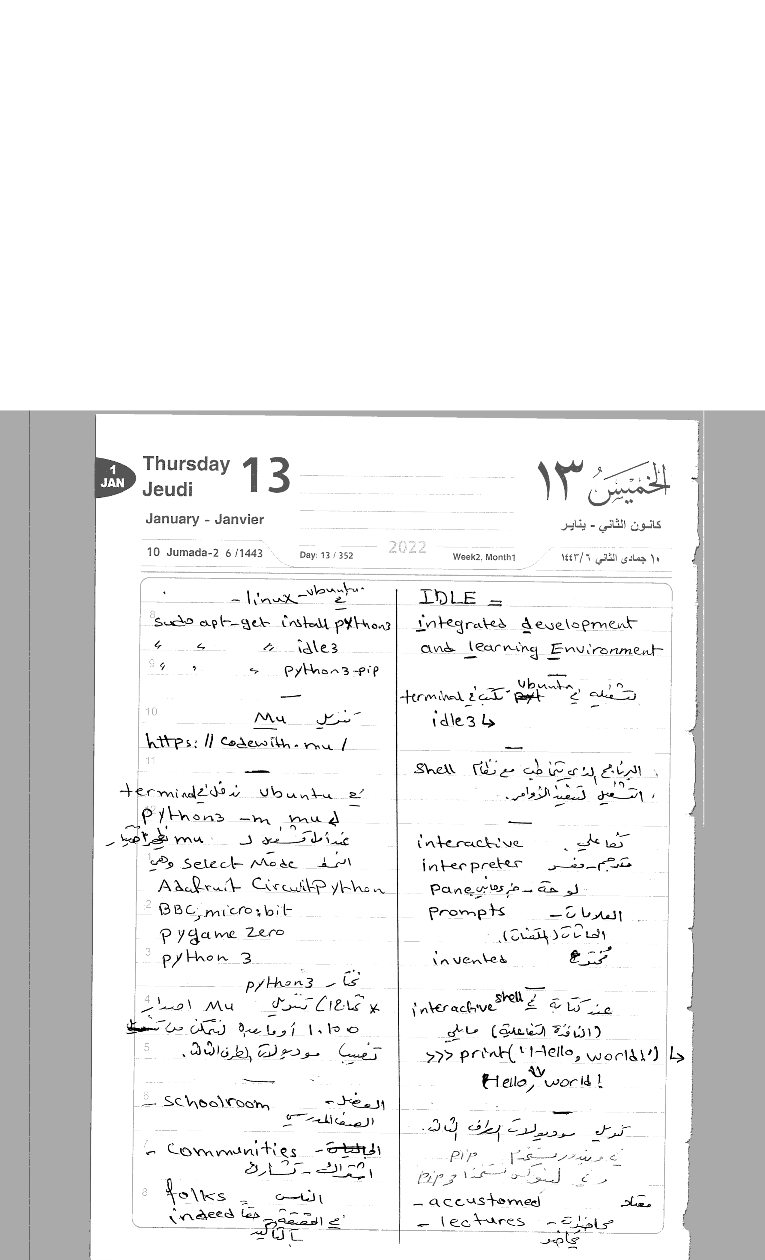

In [ ]:
# اختر نطاق الصفحات (مثال: من 1 إلى 2)
process_pdf(pages_start=3, pages_end=4, resume=True)

### **الخلية 7: الواجهة التفاعلية المتكاملة (v2)**

In [ ]:
# يُرجى تشغيل الخلية التالية أولاً لتعريف الدوال، ثم استدعاء الواجهة من هناك.

### **الخلية 8: عرض مسارات ملفات المراقبة (للإشارة)**

In [ ]:
print("\n📁 ملفات المراقبة والتطوير:")
print(f"   • سجل الأحداث: {LOG_FILE}")
print(f"   • إحصائيات المعالجة: {STATS_JSON}")
print(f"   • تصحيحات المستخدم: {FEEDBACK_CSV}")


📁 ملفات المراقبة والتطوير:
   • سجل الأحداث: /content/drive/MyDrive/Handwriting_Dataset/Logs/ocr_log_20260425_140046.log
   • إحصائيات المعالجة: /content/drive/MyDrive/Handwriting_Dataset/Logs/processing_stats.json
   • تصحيحات المستخدم: /content/drive/MyDrive/Handwriting_Dataset/Logs/user_corrections_feedback.csv


In [ ]:
# =============== الخلية 8: تصدير البيانات الموثقة فقط ===============
def export_finetuning_dataset(output_dir="hf_training_dataset", val_ratio=0.1):
    import random
    os.makedirs(output_dir, exist_ok=True)
    img_dir = os.path.join(output_dir, "images")
    os.makedirs(img_dir, exist_ok=True)

    with sqlite3.connect(DB_PATH) as conn:
        # تصدير الكلمات الموثقة سواء من واجهة الكلمات أو واجهة الجمل
        df_verified = pd.read_sql_query('''
            SELECT image_id, image_data, predicted_text, status
            FROM handwriting_data
            WHERE status IN ('verified', 'sentence_corrected')
            ORDER BY image_id
        ''', conn)

    if df_verified.empty:
        print("⚠️ لا توجد بيانات موثقة (Verified). قم بمراجعة بعض الكلمات وتأكيدها أولاً.")
        return None

    jsonl_records = []
    for _, row in df_verified.iterrows():
        filename = f"img_{row['image_id']}.png"
        filepath = os.path.join(img_dir, filename)
        with open(filepath, "wb") as f:
            f.write(row['image_data'])
        jsonl_records.append({
            "image": filename,
            "text": row['predicted_text'].strip() if row['predicted_text'] else "",
            "verified": True
        })

    random.shuffle(jsonl_records)
    split_idx = int(len(jsonl_records) * (1 - val_ratio))
    train_data = jsonl_records[:split_idx]
    val_data = jsonl_records[split_idx:]

    def save_jsonl(data, fname):
        path = os.path.join(output_dir, fname)
        with open(path, "w", encoding="utf-8") as f:
            for rec in data:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
        return path

    save_jsonl(train_data, "train.jsonl")
    save_jsonl(val_data, "val.jsonl")

    print(f"✅ تم التصدير بنجاح: {len(jsonl_records)} عينة موثقة.")
    print(f"📁 المسار: {os.path.abspath(output_dir)}")
    return output_dir

In [ ]:
def reconstruct_sentences(y_tolerance=25):
    import pandas as pd
    import sqlite3
    from langdetect import detect

    with sqlite3.connect(DB_PATH) as conn:
        words = pd.read_sql_query("SELECT * FROM handwriting_data WHERE status='verified' ORDER BY page_num, y, x", conn)

    if words.empty: return

    all_sentences = []
    for page in words['page_num'].unique():
        p_words = words[words['page_num'] == page].copy()
        lines = []
        if not p_words.empty:
            curr_line = [p_words.iloc[0].to_dict()]
            for i in range(1, len(p_words)):
                row = p_words.iloc[i].to_dict()
                if abs(row['y'] - curr_line[-1]['y']) <= y_tolerance:
                    curr_line.append(row)
                else:
                    lines.append(curr_line); curr_line = [row]
            lines.append(curr_line)

        for line in lines:
            text_preview = ' '.join([str(w['predicted_text']) for w in line])
            try: lang = detect(text_preview)
            except: lang = 'en'

            # إصلاح الترتيب: RTL للعربي (x تنازلي)
            sorted_line = sorted(line, key=lambda k: k['x'], reverse=(lang == 'ar'))
            sentence = ' '.join([str(w['predicted_text']) for w in sorted_line])
            all_sentences.append({'page': page, 'text': sentence, 'lang': lang})

    df_res = pd.DataFrame(all_sentences)
    display(df_res)
    return df_res

def extract_bilingual_vocab():
    """استخرج المفردات الإنجليزية-العربية من البيانات الموثقة"""
    with sqlite3.connect(DB_PATH) as conn:
        words = pd.read_sql_query("""
            SELECT DISTINCT predicted_text, page_num, x, y
            FROM handwriting_data
            WHERE status IN ('verified', 'sentence_corrected')
            ORDER BY page_num, y, x
        """, conn)

    if words.empty:
        print("⚠️ لا توجد كلمات موثقة.")
        return

    vocab_pairs = []
    for page in words['page_num'].unique():
        p_words = words[words['page_num'] == page].copy()
        curr_line, lines = [p_words.iloc[0].to_dict()], []

        for i in range(1, len(p_words)):
            row = p_words.iloc[i].to_dict()
            if abs(row['y'] - curr_line[-1]['y']) <= 30:
                curr_line.append(row)
            else:
                lines.append(curr_line)
                curr_line = [row]
        lines.append(curr_line)

        for line in lines:
            texts = [str(w['predicted_text']) for w in line
                     if w['predicted_text'] and str(w['predicted_text']).strip()]
            en_words = [t for t in texts
                        if t and all(ord(c) < 128 for c in t.replace(' ',''))]
            ar_words = [t for t in texts
                        if t and any('\u0600' <= c <= '\u06FF' for c in t)]
            if en_words or ar_words:
                vocab_pairs.append({
                    'english': ' | '.join(en_words),
                    'arabic':  ' | '.join(ar_words),
                    'page': page
                })

    df = pd.DataFrame(vocab_pairs)
    output = os.path.join(OUTPUT_DIR, 'bilingual_vocab.csv')
    df.to_csv(output, index=False, encoding='utf-8-sig')
    print(f"✅ تم استخراج {len(df)} زوج من المفردات")
    print(f"📁 المسار: {output}")
    display(df.head(20))
    return df

In [ ]:
# تشغيل استخراج القاموس ثنائي اللغة
vocab_df = extract_bilingual_vocab()

✅ تم استخراج 63 زوج من المفردات
📁 المسار: /content/drive/MyDrive/Handwriting_Dataset/bilingual_vocab.csv


,english,arabic,page
0,12,الأربعاء ١٢,1
1,January,الثاني | كانون | يناير,1
2,2022 | jumada - 2 | 6 /1443 | ay | Day: | 353 ...,الثاني | ٦ /١٤٤٣ | ٩,1
3,printouts | involve,,1
4,interacting with | scattered,,1
5,affection | sky | rocketed,,1
6,affectionately | stacked,,1
7,luggage | pythonistas,,1
8,idiot | serpentine | 10,,1
9,xiety | reasonable | an,,1


### **تم تحديث المشروع بنجاح**

| البند | الحالة |
|--|-------|
| 🟢 حذف البيانات القديمة (Anti-duplication) | مفعّل في `process_pdf` |
| 🟢 استخراج المفردات (Bilingual Vocab) | مضاف وجاهز للاستخدام |

In [ ]:
from huggingface_hub import HfApi, login
from peft import get_peft_model, LoraConfig, TaskType
from torch.optim import AdamW
from torch.utils.data import Dataset as TorchDataset, DataLoader

def push_to_huggingface(hf_repo_id, hf_token, local_dataset_dir="hf_training_dataset"):
    if not os.path.exists(local_dataset_dir):
        return print("⚠️ شغّل export_finetuning_dataset() أولاً.")
    login(token=hf_token)
    api = HfApi()
    try: api.create_repo(repo_id=hf_repo_id, repo_type="dataset", exist_ok=True)
    except Exception as e: print(f"Repo info: {e}")
    api.upload_folder(folder_path=local_dataset_dir, repo_id=hf_repo_id, repo_type="dataset")
    print(f"✅ تم الرفع: https://huggingface.co/datasets/{hf_repo_id}")

def finetune_trocr_lora(min_samples=100):
    global trocr_model # Moved global declaration to the beginning
    with sqlite3.connect(DB_PATH) as conn:
        df_v = pd.read_sql_query("SELECT image_data, predicted_text FROM handwriting_data WHERE status IN ('verified', 'sentence_corrected')", conn)
    if len(df_v) < min_samples: return print(f"⚠️ لديك {len(df_v)} عينة فقط. انتظر حتى {min_samples}.")
    print(f"🚀 بدء التدريب على {len(df_v)} عينة...")
    lora_config = LoraConfig(task_type=TaskType.SEQ_2_SEQ_LM, r=16, lora_alpha=32, target_modules=["query", "value"], lora_dropout=0.1)
    model = get_peft_model(trocr_model, lora_config)
    model.train()
    class HandwritingDataset(TorchDataset):
        def __init__(self, df): self.df = df
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(io.BytesIO(row['image_data'])).convert('RGB')
            pixel_values = trocr_processor(images=img, return_tensors="pt").pixel_values.squeeze()
            labels = trocr_processor.tokenizer(row['predicted_text'], return_tensors="pt", padding="max_length", max_length=50).input_ids.squeeze()
            labels[labels == trocr_processor.tokenizer.pad_token_id] = -100
            return {"pixel_values": pixel_values, "labels": labels}
    loader = DataLoader(HandwritingDataset(df_v), batch_size=4, shuffle=True)
    optimizer = AdamW(model.parameters(), lr=5e-5)
    for epoch in range(3):
        total_loss = 0
        for batch in loader:
            out = model(pixel_values=batch["pixel_values"].to(device), labels=batch["labels"].to(device))
            out.loss.backward(); optimizer.step(); optimizer.zero_grad()
            total_loss += out.loss.item()
        print(f"Epoch {epoch+1}/3 | Loss: {total_loss/len(loader):.4f}")
    lora_save_path = os.path.join(MODEL_CACHE, 'trocr_lora_finetuned')
    model.save_pretrained(lora_save_path)
    trocr_processor.save_pretrained(lora_save_path)
    trocr_model = model
    print(f"✅ تم الحفظ والتشغيل من: {lora_save_path}")

In [ ]:
def edit_correction_dict_ui():
    import json, ipywidgets as widgets
    from IPython.display import display, clear_output
    dict_path = os.path.join(OUTPUT_DIR, 'correction_dict.json')
    data = {}
    if os.path.exists(dict_path):
        with open(dict_path, 'r', encoding='utf-8') as f: data = json.load(f)

    out = widgets.Output()
    key_in = widgets.Text(description="أصلي:")
    val_in = widgets.Text(description="تصحيح:")
    def save(b):
        if key_in.value:
            data[key_in.value] = val_in.value
            with open(dict_path, 'w', encoding='utf-8') as f: json.dump(data, f, ensure_ascii=False)
            with out: clear_output(); print(f"تم حفظ {key_in.value}")

    btn = widgets.Button(description="حفظ", button_style='success')
    btn.on_click(save)
    display(widgets.VBox([key_in, val_in, btn, out]))

# edit_correction_dict_ui() # قم بإلغاء التعليق للتشغيل

In [ ]:
def launch_review_ui_v2():
    import sqlite3, pandas as pd, ipywidgets as widgets, os
    from IPython.display import display
    from datetime import datetime

    global df # Make df globally accessible within this function's scope
    df = pd.read_sql_query("SELECT * FROM handwriting_data WHERE status='unverified' ORDER BY confidence ASC", sqlite3.connect(DB_PATH))

    if df.empty:
        print("✅ لا توجد كلمات للمراجعة."); return

    current = 0
    undo_stack = [] # Stack to store actions for undo

    img = widgets.Image(format='png', width=350)
    text = widgets.Text(description="النص:")
    conf_bar = widgets.FloatProgress(min=0, max=1.0, description='الثقة:', layout={'width': '95%'})
    conf_label = widgets.HTML(value="")
    prog = widgets.IntProgress(min=0, max=len(df)-1, bar_style='info')
    info = widgets.Label()

    def update_df_from_db():
        nonlocal df
        df = pd.read_sql_query("SELECT * FROM handwriting_data WHERE status='unverified' ORDER BY confidence ASC", sqlite3.connect(DB_PATH))

    def update():
        nonlocal current
        if 0 <= current < len(df):
            row = df.iloc[current]
            img.value = row['image_data']
            text.value = str(row['predicted_text'] or '')
            c = float(row['confidence'])
            conf_bar.value = c
            conf_bar.bar_style = 'danger' if c < 0.5 else ('warning' if c < 0.8 else 'success')
            conf_label.value = f"<b>{c:.2%}</b>"
            info.value = f"{current+1}/{len(df)} | صفحة {row['page_num']}"
            prog.value = current
            btn_undo.disabled = False if undo_stack else True
        else:
            img.value = b''; text.value = ''; info.value = "🏁 اكتملت المراجعة"
            prog.value = len(df) # Set progress to max when done
            btn_undo.disabled = False if undo_stack else True

        prog.max = max(0, len(df)-1)


    def on_confirm(b):
        nonlocal current, df
        if not (0 <= current < len(df)): return

        rid = int(df.iloc[current]['image_id'])
        original_predicted_text = df.iloc[current]['predicted_text']
        corrected = text.value

        # Push current state to undo_stack before modification
        undo_stack.append({
            'type': 'confirm',
            'image_id': rid,
            'prev_predicted_text': original_predicted_text,
            'prev_status': 'unverified',
            'new_predicted_text': corrected,
            'new_status': 'verified'
        })

        with sqlite3.connect(DB_PATH) as conn:
            conn.execute("UPDATE handwriting_data SET predicted_text=?, status='verified' WHERE image_id=?", (corrected, rid))

        if original_predicted_text != corrected:
            pd.DataFrame([{
                'timestamp': datetime.now().isoformat(),
                'image_id': rid,
                'original_text': original_predicted_text,
                'corrected_text': corrected,
                'status': 'verified'
            }]).to_csv(FEEDBACK_CSV, mode='a', header=not os.path.exists(FEEDBACK_CSV), index=False, encoding='utf-8')

        df = df.drop(df.index[current]).reset_index(drop=True)
        if current >= len(df) and len(df) > 0: current = len(df) - 1
        update()

    def on_undo(b):
        nonlocal current, df
        if not undo_stack: return

        last_action = undo_stack.pop()
        if last_action['type'] == 'confirm':
            image_id = last_action['image_id']
            prev_predicted_text = last_action['prev_predicted_text']
            prev_status = last_action['prev_status']

            with sqlite3.connect(DB_PATH) as conn:
                conn.execute("UPDATE handwriting_data SET predicted_text=?, status=? WHERE image_id=?", (prev_predicted_text, prev_status, image_id))

            # Refresh df entirely to ensure correct sorting and state
            update_df_from_db()

            # Try to find the undone item and set current to its position
            try:
                current = df[df['image_id'] == image_id].index[0]
            except IndexError:
                current = 0 # Fallback if not found, or if df is empty

            update()

    def on_next(b):
        nonlocal current
        current = min(len(df)-1, current + 1)
        update()

    def on_prev(b):
        nonlocal current
        current = max(0, current - 1)
        update()

    def on_delete(b):
        nonlocal current, df
        if not (0 <= current < len(df)): return
        rid = int(df.iloc[current]['image_id'])

        # Deletion also goes into undo stack
        undo_stack.append({
            'type': 'delete',
            'image_id': rid,
            'deleted_row': df.iloc[current].to_dict() # Store the full row for restoration
        })

        with sqlite3.connect(DB_PATH) as conn:
            conn.execute("DELETE FROM handwriting_data WHERE image_id=?", (rid,))

        df = df.drop(df.index[current]).reset_index(drop=True)
        if current >= len(df) and len(df) > 0: current = len(df)-1
        update()

    btn_confirm = widgets.Button(description="✅ تأكيد", button_style='success')
    btn_next = widgets.Button(description="التالي", button_style='info')
    btn_prev = widgets.Button(description="⬅️ السابق", button_style='info')
    btn_del = widgets.Button(description="🗑️ حذف", button_style='danger')
    btn_undo = widgets.Button(description="↩️ تراجع", button_style='warning', disabled=True)

    btn_confirm.on_click(on_confirm)
    btn_next.on_click(on_next)
    btn_prev.on_click(on_prev)
    btn_del.on_click(on_delete)
    btn_undo.on_click(on_undo)

    display(widgets.VBox([
        prog, info, img, text,
        widgets.HBox([conf_bar, conf_label]),
        widgets.HBox([btn_prev, btn_undo, btn_confirm, btn_del, btn_next]) # Added undo button
    ]))
    update()

# تشغيل واجهة مراجعة الكلمات
launch_review_ui_v2()

SyntaxError: no binding for nonlocal 'df' found (1963485714.py, line 23)

### **الخلية 9: واجهة مراجعة الجمل (Sentence-Level Review UI)**
تتيح هذه الواجهة مراجعة الكلمات مجمعة في جمل لتحسين دقة التصحيح بناءً على السياق، مع تحديث تلقائي لقاموس التصحيحات.

In [ ]:
def launch_sentence_review_ui(y_tolerance=25):
    import sqlite3, pandas as pd, ipywidgets as widgets, os, io as _io
    from IPython.display import display, clear_output
    from PIL import Image
    from datetime import datetime

    with sqlite3.connect(DB_PATH) as conn:
        words_df = pd.read_sql_query("SELECT * FROM handwriting_data ORDER BY page_num, y, x", conn)

    if words_df.empty: return print("⚠️ لا توجد بيانات للمراجعة.")

    sentences = []
    for page in words_df['page_num'].unique():
        p_words = words_df[words_df['page_num'] == page].copy()
        if p_words.empty: continue

        curr_line = [p_words.iloc[0].to_dict()]
        for i in range(1, len(p_words)):
            row = p_words.iloc[i].to_dict()
            if abs(row['y'] - curr_line[-1]['y']) <= y_tolerance:
                curr_line.append(row)
            else:
                sentences.append(curr_line); curr_line = [row]
        sentences.append(curr_line)

    current_idx = 0

    img_container = widgets.HBox(layout={'overflow_x': 'scroll', 'padding': '10px'})
    sentence_input = widgets.Textarea(description="الجملة:", layout={'width': '95%', 'height': '80px'})
    info_label = widgets.Label()
    progress = widgets.IntProgress(min=0, max=len(sentences)-1, layout={'width': '95%', 'height': '20px'})

    def get_img_widget(blob):
        img = Image.open(_io.BytesIO(blob))
        buf = _io.BytesIO()
        img.save(buf, format='PNG')
        return widgets.Image(value=buf.getvalue(), format='png', width=120)

    def update_ui():
        nonlocal current_idx
        if not (0 <= current_idx < len(sentences)): return
        sent = sentences[current_idx]
        img_container.children = [get_img_widget(w['image_data']) for w in sent]
        original_text = " ".join([str(w['predicted_text'] or "") for w in sent])
        sentence_input.value = original_text
        info_label.value = f"جملة {current_idx+1} من {len(sentences)} | صفحة {sent[0]['page_num']}"
        progress.value = current_idx

    def save_current(b):
        nonlocal current_idx
        sent = sentences[current_idx]
        original = " ".join([str(w['predicted_text'] or "") for w in sent])
        corrected = sentence_input.value.strip()
        if not corrected: return

        with sqlite3.connect(DB_PATH) as conn:
            for w in sent:
                conn.execute("UPDATE handwriting_data SET status='sentence_corrected' WHERE image_id=?", (w['image_id'],))

        sent_id = f"p{sent[0]['page_num']}_y{sent[0]['y']}"
        if original != corrected:
            pd.DataFrame([{
                'timestamp': datetime.now().isoformat(),
                'image_id': None,
                'original_text': original,
                'corrected_text': corrected,
                'status': f'sent_rev_{sent_id}'
            }]).to_csv(FEEDBACK_CSV, mode='a', header=not os.path.exists(FEEDBACK_CSV), index=False, encoding='utf-8')

            orig_words = original.split()
            corr_words = corrected.split()
            if len(orig_words) == len(corr_words):
                derived = []
                for o, c in zip(orig_words, corr_words):
                    if o != c:
                        derived.append({'timestamp': datetime.now().isoformat(), 'image_id': None, 'original_text': o, 'corrected_text': c, 'status': 'sentence_derived'})
                if derived: pd.DataFrame(derived).to_csv(FEEDBACK_CSV, mode='a', header=False, index=False, encoding='utf-8')
        print(f"✅ تم حفظ الجملة {current_idx+1}")
        current_idx = min(len(sentences)-1, current_idx + 1)
        update_ui()

    def on_next(b):
        nonlocal current_idx
        current_idx = min(len(sentences)-1, current_idx + 1)
        update_ui()

    def on_prev(b):
        nonlocal current_idx
        current_idx = max(0, current_idx - 1)
        update_ui()

    btn_save = widgets.Button(description="✅ حفظ وتأكيد", button_style='success')
    btn_next = widgets.Button(description="التالي ⮕", button_style='info')
    btn_prev = widgets.Button(description="⬅ السابق", button_style='info')
    btn_save.on_click(save_current)
    btn_next.on_click(on_next)
    btn_prev.on_click(on_prev)

    display(widgets.VBox([progress, info_label, img_container, sentence_input, widgets.HBox([btn_prev, btn_save, btn_next])]))
    update_ui()

launch_sentence_review_ui()

### **الخلية 10: واجهة التدقيق والوسم الذكي المتكاملة (TrOCR + Tesseract + PDF Export)**

تدمج هذه الواجهة المحركات القوية TrOCR و Tesseract لتقديم أفضل التوقعات، وتوفر أدوات للتصحيح السريع، وتتبع التقدم نحو التدريب المستمر، بالإضافة إلى إمكانية تصدير الأرشيف الموثق إلى ملف PDF.

In [ ]:
import os, sqlite3, io, cv2, numpy as np, pandas as pd
import pytesseract
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime
from fpdf import FPDF

# --- Paths and global variables (assuming they are set in previous cells) ---
OUTPUT_DIR = '/content/drive/MyDrive/Handwriting_Dataset'
DB_PATH = os.path.join(OUTPUT_DIR, 'handwriting_data.db')

# Ensure trocr_processor, trocr_model, and device are loaded from previous cells (e.g., Cell 3)
# Example (should be global):
# from transformers import TrOCRProcessor, VisionEncoderDecoderModel
# import torch
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# trocr_processor = TrOCRProcessor.from_pretrained("David-Magdy/TR_OCR_LARGE")
# trocr_model = VisionEncoderDecoderModel.from_pretrained("David-Magdy/TR_OCR_LARGE").to(device)

# --- Helper Functions ---
# Function to get top-k predictions from TrOCR (provided by user in earlier context)
def get_top_k(image_bytes, k=3):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    pixel_values = trocr_processor(images=img, return_tensors="pt").pixel_values.to(device)
    outputs = trocr_model.generate(
        pixel_values,
        max_length=50,
        num_beams=5,
        num_return_sequences=k
    )
    preds = [trocr_processor.batch_decode(s.unsqueeze(0), skip_special_tokens=True)[0].strip() for s in outputs]
    return list(dict.fromkeys(preds)) # Remove duplicates

# Function to get prediction from Tesseract
def get_tesseract_pred(image_bytes):
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
    # Simple image enhancement for Tesseract
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    # Modified: Added lang='ara+eng' as per user's request
    return pytesseract.image_to_string(img, lang='ara+eng', config='--psm 7').strip()

# --- PDF Export Functionality ---
class OCR_Report(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Handwriting Archive - Dr. Abdulmalek', 0, 1, 'C')
        self.ln(5)

def export_to_pdf(df_data, output_path):
    pdf = OCR_Report()
    pdf.add_page()
    pdf.set_font("Arial", size=11)
    for idx, row in df_data.iterrows():
        img = Image.open(io.BytesIO(row['image_data']))
        tmp_path = f"tmp_{idx}.png"
        img.save(tmp_path)
        y_pos = pdf.get_y()
        pdf.image(tmp_path, x=10, y=y_pos, w=40)
        pdf.set_xy(55, y_pos + 5)
        pdf.multi_cell(0, 10, txt=f"Text: {row['predicted_text']}")
        pdf.ln(10)
        os.remove(tmp_path)
        if pdf.get_y() > 260: pdf.add_page()
    pdf.output(output_path)

# --- UI Widgets Definition ---
img_widget = widgets.Image(format='png', width=400)
text_input = widgets.Text(description="التصحيح:", layout=widgets.Layout(width='95%'))
progress = widgets.IntProgress(layout=widgets.Layout(width='95%'), bar_style='info')
info_label = widgets.Label()

# Suggestion buttons (TrOCR 1, TrOCR 2, Tesseract)
opt_btns = [widgets.Button(layout=widgets.Layout(width='32%'), button_style='warning') for _ in range(3)]

# Control buttons
prev_btn = widgets.Button(description="⬅️ السابق", button_style='info')
next_btn = widgets.Button(description="التالي ➡️", button_style='success')
del_btn = widgets.Button(description="حذف 🗑️", button_style='danger')
export_btn = widgets.Button(description="تصدير PDF 📄", button_style='primary')

# --- Data Logic ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM handwriting_data ORDER BY image_id", conn)
current_idx = 0

def update_ui():
    global current_idx
    if len(df) == 0:
        info_label.value = "🏁 لا توجد بيانات للمراجعة!"
        img_widget.value = b''
        text_input.value = ''
        progress.value = 0
        progress.max = 0
        for btn in opt_btns: btn.disabled = True
        next_btn.disabled = True
        prev_btn.disabled = True
        del_btn.disabled = True
        export_btn.disabled = True
        return

    if current_idx < 0: current_idx = 0
    if current_idx >= len(df): current_idx = len(df) - 1 # Adjust if somehow went past end

    row = df.iloc[current_idx]
    img_bytes = row['image_data']
    img_widget.value = img_bytes

    # Get predictions from both engines
    trocr_preds = get_top_k(img_bytes, k=2)
    tess_pred = get_tesseract_pred(img_bytes)

    all_preds = list(dict.fromkeys(trocr_preds + [tess_pred])) # Merge without duplicates

    for i in range(3):
        if i < len(all_preds):
            opt_btns[i].description = all_preds[i]
            opt_btns[i].disabled = False
        else:
            opt_btns[i].disabled = True

    text_input.value = all_preds[0] if all_preds else ""
    progress.value = current_idx
    progress.max = len(df) - 1
    ready_count = df[df['status'] == 'yes'].shape[0]
    info_label.value = f"ID: {row['image_id']} | جاهز للتدريب: {ready_count}/500 | {current_idx + 1}/{len(df)}"
    text_input.focus()

def on_click_next(_):
    global current_idx, df
    if not (0 <= current_idx < len(df)): return # Ensure current_idx is valid

    val = text_input.value.strip()
    img_id = int(df.iloc[current_idx]['image_id'])

    with sqlite3.connect(DB_PATH) as c:
        c.execute("UPDATE handwriting_data SET predicted_text=?, status='yes' WHERE image_id=?", (val, img_id))

    # Update dataframe in memory
    df.loc[current_idx, 'status'] = 'yes'
    df.loc[current_idx, 'predicted_text'] = val

    current_idx += 1
    if current_idx >= len(df):
        info_label.value = "🏁 اكتملت المراجعة! لا توجد المزيد من الكلمات."
        img_widget.value = b''
        text_input.value = ''
        for btn in opt_btns: btn.disabled = True
        next_btn.disabled = True
        prev_btn.disabled = True
        del_btn.disabled = True
        return
    update_ui()

def on_click_prev(_):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        update_ui()

def on_click_del(_):
    global current_idx, df
    if not (0 <= current_idx < len(df)): return

    img_id_to_delete = int(df.iloc[current_idx]['image_id'])
    with sqlite3.connect(DB_PATH) as c:
        c.execute("DELETE FROM handwriting_data WHERE image_id=?", (img_id_to_delete,))

    # Re-read from DB to get updated df, or manually remove and re-index
    df = pd.read_sql_query("SELECT * FROM handwriting_data ORDER BY image_id", sqlite3.connect(DB_PATH))

    if len(df) == 0:
        current_idx = 0
    elif current_idx >= len(df):
        current_idx = len(df) - 1

    update_ui()

def on_export(_):
    final_df = df[df['status'] == 'yes']
    if final_df.empty:
        info_label.value = "⚠️ لا توجد كلمات جاهزة للتصدير (status='yes')."
        return

    path = os.path.join(OUTPUT_DIR, f"Archive_{datetime.now().strftime('%Y%m%d_%H%M')}.pdf")
    export_to_pdf(final_df, path)
    info_label.value = f"✅ تم التصدير لـ: {os.path.basename(path)}"

# --- Event Bindings ---
next_btn.on_click(on_click_next)
prev_btn.on_click(on_click_prev)
del_btn.on_click(on_click_del)
export_btn.on_click(on_export)
for btn in opt_btns: btn.on_click(lambda b: [setattr(text_input, 'value', b.description), on_click_next(None)])

# --- Display UI ---
display(widgets.VBox([
    widgets.HTML("<h2>🩺 نظام الأرشفة والتدقيق المتكامل</h2>"),
    progress, info_label,
    widgets.Box([img_widget], layout={'justify_content': 'center', 'border': '1px solid #ccc', 'margin': '10px'}),
    widgets.HTML("<b>اختر أدق نتيجة (TrOCR / Tesseract):</b>"),
    widgets.HBox(opt_btns),
    text_input,
    widgets.HBox([prev_btn, del_btn, next_btn, export_btn], layout={'justify_content': 'space-between'})
]))

update_ui()